In [2]:
# Import all libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
sms_data = pd.read_csv("sms.csv",usecols=[0,1],sep=",")

In [4]:
sms_data.head()

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
sms_data.shape

(5572, 2)

In [6]:
sms_data.isnull().sum()

Label      0
Message    0
dtype: int64

In [7]:
sms_data.duplicated().sum()

403

In [8]:
sms_data.drop_duplicates(inplace=True)
sms_data.reset_index(drop=True , inplace=True)

In [9]:
sms_data.head()

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
sms_data.duplicated().sum()

0

In [11]:
sms_data.shape

(5169, 2)

In [12]:
sms_data["Label"].value_counts()

Label
ham     4516
spam     653
Name: count, dtype: int64

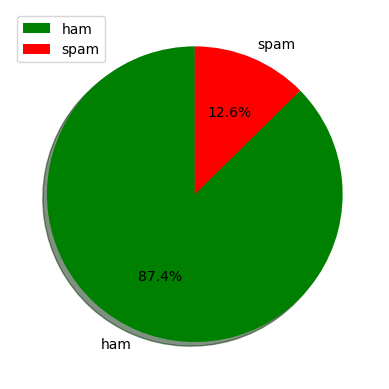

In [13]:
data = sms_data["Label"].value_counts()

plt.pie(data , autopct= "%1.1f%%" , labels= data.index , startangle=90 , shadow=True ,colors=["g","r"] )
plt.legend()
plt.show()

In [14]:
email_data = pd.read_csv("emails.csv", usecols=[1,2] , sep=",")

In [15]:
email_data.head()

,Label,Message
0,ham,Subject: enron methanol ; meter # : 988291\nth...
1,ham,"Subject: hpl nom for january 9 , 2001\n( see a..."
2,ham,"Subject: neon retreat\nho ho ho , we ' re arou..."
3,spam,"Subject: photoshop , windows , office . cheap ..."
4,ham,Subject: re : indian springs\nthis deal is to ...


In [16]:
email_data.shape

(5171, 2)

In [17]:
email_data.duplicated().sum()

178

In [18]:
email_data.drop_duplicates(inplace=True)
email_data.reset_index(drop=True , inplace=True)

In [19]:
email_data.duplicated().sum()

0

In [20]:
email_data["Label"].value_counts()

Label
ham     3531
spam    1462
Name: count, dtype: int64

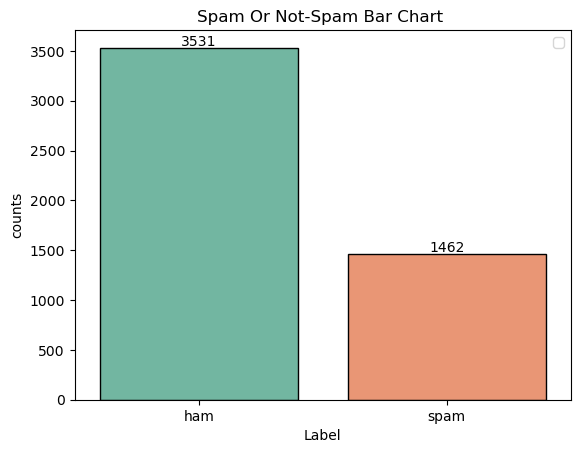

In [69]:
counts = email_data["Label"].value_counts()

sns.barplot(x=counts.index , y=counts.values ,edgecolor="black" , palette="Set2" )

for i , v in enumerate(email_data["Label"].value_counts().values):
    plt.text(i , v+20 , str(v) , ha="center")

plt.title("Spam Or Not-Spam Bar Chart ")
plt.xlabel("Label")
plt.ylabel("counts")
plt.legend()
plt.show()

In [22]:
final_data = pd.concat([email_data , sms_data] , axis=0 , ignore_index=True)

In [23]:
final_data.head()

,Label,Message
0,ham,Subject: enron methanol ; meter # : 988291\nth...
1,ham,"Subject: hpl nom for january 9 , 2001\n( see a..."
2,ham,"Subject: neon retreat\nho ho ho , we ' re arou..."
3,spam,"Subject: photoshop , windows , office . cheap ..."
4,ham,Subject: re : indian springs\nthis deal is to ...


In [24]:
final_data.shape

(10162, 2)

In [25]:
final_data = final_data[["Label","Message"]]

In [26]:
final_data.isnull().sum()

Label      0
Message    0
dtype: int64

In [27]:
final_data.to_csv("spamham.csv",index=False)

In [28]:
data = pd.read_csv("spamham.csv",sep=",")
data.head()

,Label,Message
0,ham,Subject: enron methanol ; meter # : 988291\nth...
1,ham,"Subject: hpl nom for january 9 , 2001\n( see a..."
2,ham,"Subject: neon retreat\nho ho ho , we ' re arou..."
3,spam,"Subject: photoshop , windows , office . cheap ..."
4,ham,Subject: re : indian springs\nthis deal is to ...


In [29]:
data.shape

(10162, 2)

In [30]:
from collections import Counter
import nltk

In [31]:
#for non-spam : 

count_1 = Counter(" ".join(data[data["Label"] == "ham"]["Message"]).split()).most_common(20)

df1 = pd.DataFrame.from_dict(count_1)

df1 = df1.rename(columns={0 : "words_in_non_spam" , 1 : "count"})

df1

,words_in_non_spam,count
0,-,76023
1,/,36572
2,.,34725
3,",",28924
4,:,20058
5,the,18855
6,to,16295
7,ect,13690
8,@,12020
9,and,8484


In [32]:
#for spam : 

count_2 = Counter(" ".join(data[data["Label"] == "spam"]["Message"]).split()).most_common(20)

df2 = pd.DataFrame.from_dict(count_2)

df2 = df2.rename(columns={0 : "words_in_spam" , 1 : "counts"})

df2

,words_in_spam,counts
0,.,19401
1,",",11201
2,-,7975
3,the,7391
4,/,5697
5,to,5660
6,and,4992
7,:,4602
8,of,4562
9,a,4083


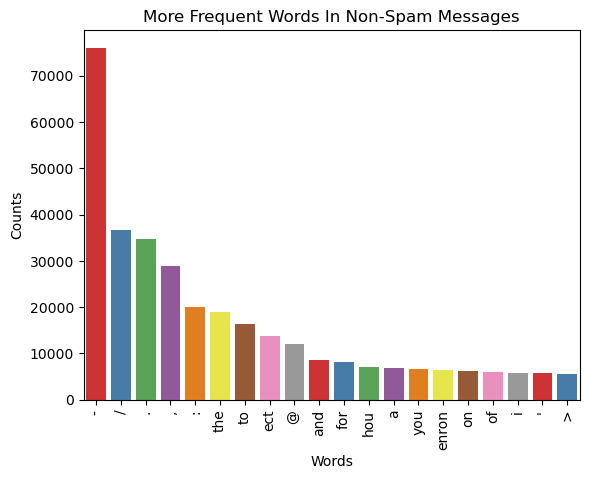

In [33]:
# for non-spam words bar chart :

sns.barplot(x = "words_in_non_spam" , y="count" , data=df1 , palette="Set1")
plt.title("More Frequent Words In Non-Spam Messages")
plt.xlabel("Words")
plt.ylabel("Counts")
plt.xticks(rotation=90)
plt.show()

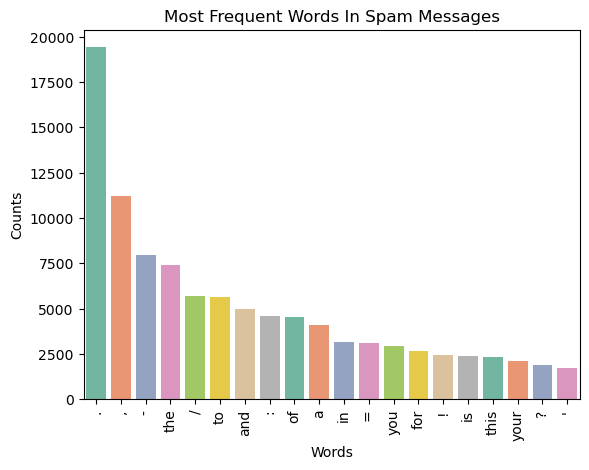

In [34]:
#for spam words bar chart :

sns.barplot(x="words_in_spam" , y="counts" , data = df2 , palette="Set2")
plt.title("Most Frequent Words In Spam Messages")
plt.xlabel("Words")
plt.ylabel("Counts")
plt.xticks(rotation=90)
plt.show()

In [35]:
from nltk.tokenize import word_tokenize   # Splits a sentence into individual words 

from nltk.corpus import stopwords        # Provides a list of common words (like 'is', 'the') to remove from text

from nltk.stem import PorterStemmer      # Converts words to their root form (Exa :-  'playing' -> 'play')

In [36]:
data["Message"] = data["Message"].str.lower()  # Convert all text to lowercase

data["Message"] = data["Message"].str.replace(r"\W+" , " ") #Remove special characters and punctuation, keep only words 

data["Message"] = data["Message"].str.replace(r"\s+"," ") #Replace multiple spaces with a single space

data["Message"] = data["Message"].str.strip() #Remove Spaces

data["Message"] = data["Message"].str.replace(r"\b\w\b" , "") #Remove single character (Exa - "a" , "i" , etc..)

data['Message'] = data['Message'].str.replace(r"\b\w{1,2}\b", "") # Remove very short words (1–2 characters) which are often not useful for analysis

data["Message"] = data["Message"].str.replace(r"\s+" , " ") # clean up extra spaces after removing Words 

In [37]:
data.head()

,Label,Message
0,ham,subject: enron methanol ; meter # : 988291\nth...
1,ham,"subject: hpl nom for january 9 , 2001\n( see a..."
2,ham,"subject: neon retreat\nho ho ho , we ' re arou..."
3,spam,"subject: photoshop , windows , office . cheap ..."
4,ham,subject: re : indian springs\nthis deal is to ...


In [38]:
stopwords = set(stopwords.words("english"))

ps = PorterStemmer()

def stemming(message):
    message = message.split()
    message = [ps.stem(i) for i in message if i not in stopwords]
    return " ".join(message)

In [39]:
#Example : 
message = " This i love Learning English and Playing Cricket"
stemming(message)

'thi love learn english play cricket'

In [40]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatizing(message):
    message  = message.split()
    message = [lemmatizer.lemmatize(i) for i in message if i not in stopwords]
    return " ".join(message)

In [41]:
#Example : -
message = "I love This team and players"
lemmatizing(message)

'I love This team player'

In [42]:
data["Message"] = data["Message"].apply(lemmatizing)
#lemmatizing is more meaningful than stemming

In [43]:
data.head()

,Label,Message
0,ham,subject: enron methanol ; meter # : 988291 fol...
1,ham,"subject: hpl nom january 9 , 2001 ( see attach..."
2,ham,"subject: neon retreat ho ho ho , ' around wond..."
3,spam,"subject: photoshop , window , office . cheap ...."
4,ham,subject: : indian spring deal book teco pvr re...


In [44]:
print(data["Message"][0].split()) ## word_tokenize is used to split the sentence into words, it is a part of nltk library

['subject:', 'enron', 'methanol', ';', 'meter', '#', ':', '988291', 'follow', 'note', 'gave', 'monday', ',', '4', '/', '3', '/', '00', '{', 'preliminary', 'flow', 'data', 'provided', 'daren', '}', '.', 'please', 'override', 'pop', "'", 'daily', 'volume', '{', 'presently', 'zero', '}', 'reflect', 'daily', 'activity', 'obtain', 'gas', 'control', '.', 'change', 'needed', 'asap', 'economics', 'purpose', '.']


In [45]:
from sklearn.feature_extraction import text

X = text.CountVectorizer(lowercase=True)
X = X.fit_transform(data["Message"]).toarray()
y = data["Label"]

In [49]:
print(X)

[[1 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [55]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

print(y)

[0 0 0 ... 0 0 0]


In [59]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.3 , random_state= 42)

X_train.shape , X_test.shape , y_train.shape , y_test.shape

((7113, 51928), (3049, 51928), (7113,), (3049,))

In [60]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train , y_train)

MultinomialNB()

In [61]:
y_pred = model.predict(X_test)
print(y_pred)

[0 0 1 ... 0 0 1]


In [64]:
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix

print(f"Accuracy Score Is : {accuracy_score(y_test , y_pred)}\n")

print(f"Classification Report : \n {classification_report(y_test , y_pred)}\n")

print(f"Confusion Matrix :\n {confusion_matrix(y_test , y_pred)}")

Accuracy Score Is : 0.9498196129878649

Classification Report : 
               precision    recall  f1-score   support

           0       0.98      0.95      0.97      2404
           1       0.84      0.94      0.89       645

    accuracy                           0.95      3049
   macro avg       0.91      0.95      0.93      3049
weighted avg       0.95      0.95      0.95      3049


Confusion Matrix :
 [[2287  117]
 [  36  609]]
